<a href="https://colab.research.google.com/github/vinayakjatoth/Predict-Fuel-Efficiency/blob/main/Predicting_Fuel_Efficiency_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler # Added StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [143]:
import pandas as pd
df = pd.read_csv('/content/sample_data/auto-mpg.csv')
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [144]:
df.shape

(398, 9)

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [146]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [147]:
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [148]:
print(df.shape)
df = df[df['horsepower'] != '?']
print(df.shape)

(398, 9)
(392, 9)


In [149]:
df['horsepower'] = df['horsepower'].astype(int)
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [150]:
df.nunique()

,0
mpg,127
cylinders,5
displacement,81
horsepower,93
weight,346
acceleration,95
model year,13
origin,3
car name,301


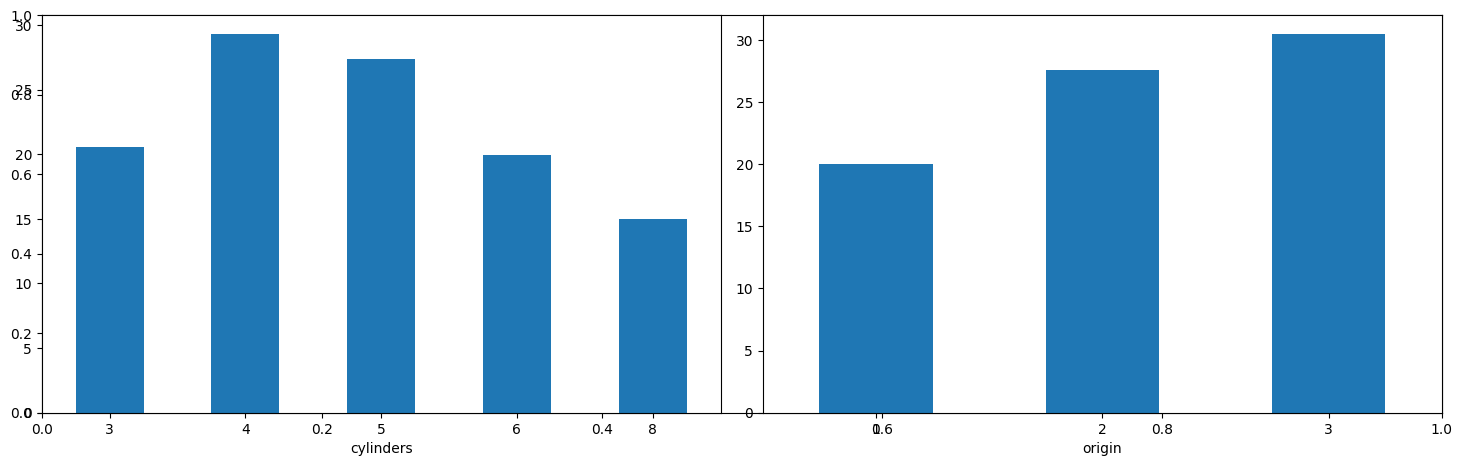

In [151]:
import matplotlib.pyplot as plt
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

plt.subplots(figsize=(15, 5))
for i, col in enumerate(['cylinders', 'origin']):
    plt.subplot(1, 2, i+1)
    x = numeric_df.groupby(col).mean()['mpg']
    x.plot.bar()
    plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

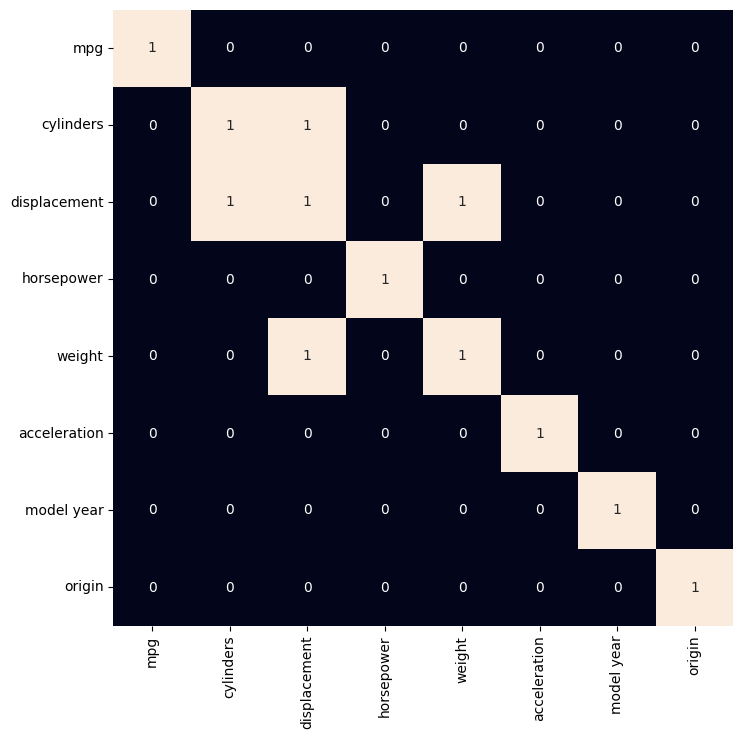

In [152]:
import seaborn as sb
plt.figure(figsize=(8, 8))
sb.heatmap(numeric_df.corr() > 0.9,
		annot=True,
		cbar=False)
plt.show()

In [153]:
df.drop('displacement',
        axis=1,
        inplace=True)

In [154]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = df.drop(['mpg', 'car name'], axis=1)
target = df['mpg'].values

X_train, X_val, \
    Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.2,
                                      random_state=22)

# Initialize and fit the StandardScaler on the training data
global_scaler = StandardScaler() # Assign scaler to a global variable for later use
X_train_scaled = global_scaler.fit_transform(X_train)
X_val_scaled = global_scaler.transform(X_val)

# Update X_train and X_val to use the scaled versions (as numpy arrays)
X_train = X_train_scaled
X_val = X_val_scaled

X_train.shape, X_val.shape

((313, 6), (79, 6))

In [155]:
import tensorflow as tf
AUTO = tf.data.experimental.AUTOTUNE

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, Y_train))
    .batch(32)
    .prefetch(AUTO)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, Y_val))
    .batch(32)
    .prefetch(AUTO)
)

def preprocess_new_data(new_df):
    # Make a copy to avoid SettingWithCopyWarning
    new_df = new_df.copy()

    # Clean 'horsepower' column if it contains '?'
    if 'horsepower' in new_df.columns:
        if (new_df['horsepower'] == '?').any():
            new_df = new_df[new_df['horsepower'] != '?']
        new_df['horsepower'] = new_df['horsepower'].astype(int)

    # Drop 'displacement' and 'car name' columns if they exist
    if 'displacement' in new_df.columns:
        new_df = new_df.drop('displacement', axis=1)
    if 'car name' in new_df.columns:
        new_df = new_df.drop('car name', axis=1)

    # Drop 'mpg' if it exists (target variable)
    if 'mpg' in new_df.columns:
        new_df = new_df.drop('mpg', axis=1)

    # Ensure the order of columns matches the training features before scaling
    # Assuming 'features' DataFrame was created using df.drop(['mpg', 'car name'], axis=1)
    # and columns are in the same order. If not, explicitly reorder new_df columns.
    expected_columns = ['cylinders', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
    new_df = new_df[expected_columns]

    # Scale the features using the globally defined scaler
    scaled_features = global_scaler.transform(new_df)
    return scaled_features


In [156]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=[6]),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation='relu')
])

model.compile(
    loss='mae',
    optimizer='adam',
    metrics=['mape', tf.keras.metrics.MeanSquaredError(), tf.keras.metrics.R2Score()]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    verbose=0 # Suppress verbose output during training
)

# Convert the history.history dict to a pandas DataFrame
history_df = pd.DataFrame(history.history)

# Display the training history
display(history_df.head())

,loss,mape,mean_squared_error,r2_score,val_loss,val_mape,val_mean_squared_error,val_r2_score
0,21.629833,90.684036,532.366211,-8.147997,21.998869,98.062943,552.175415,-6.931743
1,18.969984,78.313988,451.500214,-6.758423,21.536951,95.755577,532.988831,-6.656136
2,17.089382,68.983444,410.460968,-6.053219,20.841145,91.961006,507.292816,-6.287025
3,15.641943,60.356804,386.113739,-5.634845,19.741705,85.462029,472.120636,-5.781793
4,14.676743,55.501514,368.720642,-5.335968,18.837805,81.250145,436.511169,-5.270280


In [157]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=[X_train.shape[1]]),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation='relu')
])

In [158]:
model.compile(
    loss='mae',
    optimizer='adam',
    metrics=['mape', tf.keras.metrics.MeanSquaredError(), tf.keras.metrics.R2Score()]
)

In [159]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    verbose=0 # Suppress verbose output during training
)

# Convert the history.history dict to a pandas DataFrame
history_df = pd.DataFrame(history.history)

# Display the training history
display(history_df.head())

,loss,mape,mean_squared_error,r2_score,val_loss,val_mape,val_mean_squared_error,val_r2_score
0,21.741865,92.878777,518.912537,-7.916814,21.864290,98.075211,539.048157,-6.743176
1,18.621355,82.324158,376.328735,-5.466703,21.173233,95.746635,499.067780,-6.168876
2,16.658167,75.660408,307.775452,-4.288707,20.436413,93.251999,459.194427,-5.596114
3,15.128744,70.465416,261.874847,-3.499967,19.786144,91.050186,426.124939,-5.121087
4,13.476283,64.891068,220.563202,-2.790082,19.262503,89.260254,401.128510,-4.762024


In [160]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,621 (811.02 KB)

 Trainable params: 68,865 (269.00 KB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 137,732 (538.02 KB)

In [161]:
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor the validation loss
    patience=10,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

history = model.fit(train_ds,
                    epochs=100, # Increased epochs for potentially better convergence with scaled data
                    validation_data=val_ds,
                    callbacks=[early_stopping])

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.1150 - mape: 15.9160 - mean_squared_error: 30.1137 - r2_score: 0.4825 - val_loss: 4.5469 - val_mape: 23.6427 - val_mean_squared_error: 51.4073 - val_r2_score: 0.2616
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0995 - mape: 15.6697 - mean_squared_error: 30.1486 - r2_score: 0.4819 - val_loss: 4.4345 - val_mape: 23.2104 - val_mean_squared_error: 49.5040 - val_r2_score: 0.2889
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2516 - mape: 16.4450 - mean_squared_error: 31.7653 - r2_score: 0.4542 - val_loss: 4.6711 - val_mape: 24.2339 - val_mean_squared_error: 52.3433 - val_r2_score: 0.2481
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.1405 - mape: 16.0467 - mean_squared_error: 30.0482 - r2_score: 0.4837 - val_loss: 4.5345 - val_mape: 23.8142 - val_mean_squared_error: 52.1320 - val_r2_score: 0.2511
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0271 - mape: 15.5512 - mean_squ

In [162]:
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mape,mean_squared_error,r2_score,val_loss,val_mape,val_mean_squared_error,val_r2_score
0,3.114965,15.915991,30.113693,0.482537,4.546941,23.642706,51.407257,0.261559
1,3.099504,15.669686,30.148605,0.481937,4.434519,23.210365,49.504040,0.288898
2,3.251591,16.444998,31.765331,0.454156,4.671111,24.233940,52.343319,0.248113
3,3.140471,16.046721,30.048199,0.483662,4.534540,23.814249,52.132023,0.251148
4,3.027068,15.551225,29.373650,0.495253,4.380504,22.570690,47.865799,0.312430


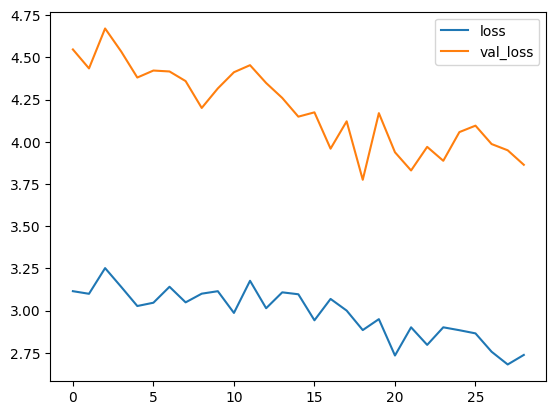

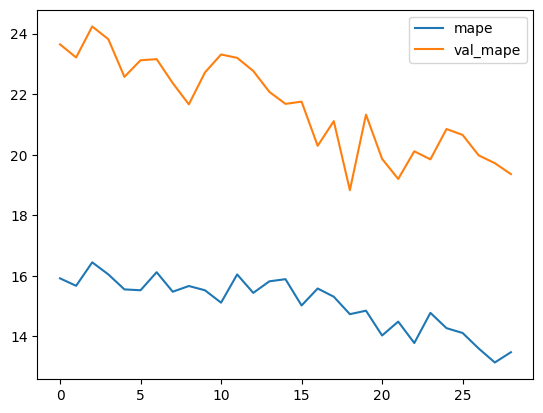

In [163]:
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['mape', 'val_mape']].plot()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


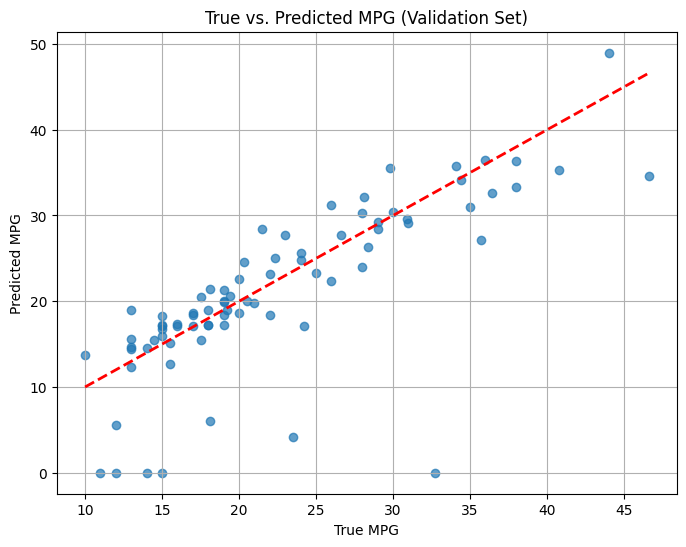

In [164]:
y_pred = model.predict(X_val)

plt.figure(figsize=(8, 6))
plt.scatter(Y_val, y_pred, alpha=0.7)
plt.xlabel('True MPG')
plt.ylabel('Predicted MPG')
plt.title('True vs. Predicted MPG (Validation Set)')
plt.plot([Y_val.min(), Y_val.max()], [Y_val.min(), Y_val.max()], 'k--', lw=2, color='red') # Diagonal line for perfect prediction
plt.grid(True)
plt.show()

In [165]:
model.save('auto_mpg_model.h5')

In [166]:
loss, mape, mse, r2 = model.evaluate(val_ds)
print(f"Final R2 Score on Validation Set: {r2:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7749 - mape: 18.8280 - mean_squared_error: 39.0356 - r2_score: 0.4393
Final R2 Score on Validation Set: 0.4393


### Comparing R2 Score and Mean Absolute Error (MAE)

Both R2 Score and Mean Absolute Error (MAE) are crucial metrics for evaluating regression models, but they provide different insights into model performance.

**R2 Score (Coefficient of Determination)**:
*   **Value:** 0.5578
*   **Interpretation:** The R2 score measures the proportion of the variance in the dependent variable that is predictable from the independent variables. A score of 0.5578 means that approximately **55.78% of the variability in MPG can be explained by your model's features**. The remaining variance is unexplained.
*   **Range:** Typically ranges from 0 to 1 (or can be negative if the model is worse than simply predicting the mean). Higher values indicate a better fit.
*   **Strengths:** Provides a relative measure of fit, making it easy to understand how much of the target's variance the model captures.
*   **Weaknesses:** Can be misleading if not interpreted carefully, as a high R2 doesn't necessarily mean the model is good for predictions, especially if there's overfitting. It also doesn't tell you the magnitude of errors.

**Mean Absolute Error (MAE)**:
*   **Value:** 2.8477
*   **Interpretation:** The MAE is the average of the absolute differences between the predicted and actual values. An MAE of 2.8477 means that, on average, your model's predictions for MPG are off by approximately **2.85 units (e.g., miles per gallon)** from the actual values.
*   **Range:** Non-negative values. Lower values indicate better accuracy.
*   **Strengths:** Easy to understand and interpret because it's in the same units as the target variable. It is also more robust to outliers compared to Mean Squared Error (MSE) because it doesn't square the errors.
*   **Weaknesses:** Does not penalize large errors as much as MSE, which might be a disadvantage if large errors are particularly undesirable.

**Comparison and Use Cases:**
*   **R2 Score** is excellent for understanding the **explanatory power** of your model – how well the features account for the variation in the target. It helps answer the question: "How much of the total variance in MPG does my model capture?"
*   **MAE** is excellent for understanding the **typical magnitude of prediction errors** in the original units of the target variable. It helps answer the question: "How far off are my predictions, on average, in terms of actual MPG values?"

In your case, an R2 of 0.5578 suggests a moderate explanatory power. An MAE of 2.8477 means that, on average, the predictions are within about 2.85 MPG of the true values. Whether this MAE is acceptable depends on the domain and the specific requirements for prediction accuracy. For instance, if small MPG differences are critical, you might want to further reduce the MAE.

The model has been saved as `auto_mpg_model.h5`. You can load it later using `tf.keras.models.load_model('auto_mpg_model.h5')`.